# Trader Performance vs Bitcoin Market Sentiment
**Datasets:** Hyperliquid historical trades (211,224 rows, 32 accounts) + Bitcoin Fear/Greed Index (2018-2025)

This notebook merges trade-level data with the daily Fear/Greed classification and explores
how trader behaviour and profitability shift across sentiment regimes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
hist = pd.read_csv("data/historical_data.csv.gz")
fg = pd.read_csv("data/fear_greed_index.csv")
print(hist.shape, fg.shape)
hist.head(2)

In [3]:
plt.rcParams['figure.figsize'] = (9,4.5)
plt.rcParams['axes.grid'] = True

## 1. Data Cleaning & Merge
Parse timestamps, derive a `date` key, and join trades to the daily sentiment classification.

In [4]:
hist['Timestamp IST'] = pd.to_datetime(hist['Timestamp IST'], format='%d-%m-%Y %H:%M')
hist['date'] = hist['Timestamp IST'].dt.date.astype(str)
fg['date'] = pd.to_datetime(fg['date']).dt.date.astype(str)

df = hist.merge(fg[['date','classification','value']], on='date', how='left')
df = df.dropna(subset=['classification'])

sent_map = {'Extreme Fear':'Fear','Fear':'Fear','Neutral':'Neutral','Greed':'Greed','Extreme Greed':'Greed'}
df['sentiment_simple'] = df['classification'].map(sent_map)
print(f"Merged rows: {len(df):,} | Accounts: {df['Account'].nunique()}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
df['classification'].value_counts()

Merged rows: 211,218 | Accounts: 32
Date range: 2023-05-01 to 2025-05-01


classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

## 2. Performance by Sentiment Regime (5 levels)
Total/avg PnL, win rate, average trade size and fees for each Fear-Greed bucket.

In [5]:
order5 = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']
g = df.groupby('classification')
summary5 = pd.DataFrame({
    'trades': g.size(),
    'total_pnl': g['Closed PnL'].sum(),
    'avg_pnl': g['Closed PnL'].mean(),
    'win_rate_%': g.apply(lambda x: (x['Closed PnL']>0).mean()*100),
    'avg_size_usd': g['Size USD'].mean(),
    'avg_fee': g['Fee'].mean(),
}).reindex(order5).round(2)
summary5

,trades,total_pnl,avg_pnl,win_rate_%,avg_size_usd,avg_fee
classification,,,,,,
Extreme Fear,21400,739110.25,34.54,37.06,5349.73,1.12
Fear,61837,3357155.44,54.29,42.08,7816.11,1.50
Neutral,37686,1292920.68,34.31,39.70,4782.73,1.04
Greed,50303,2150129.27,42.74,38.48,5736.88,1.25
Extreme Greed,39992,2715171.31,67.89,46.49,3112.25,0.68


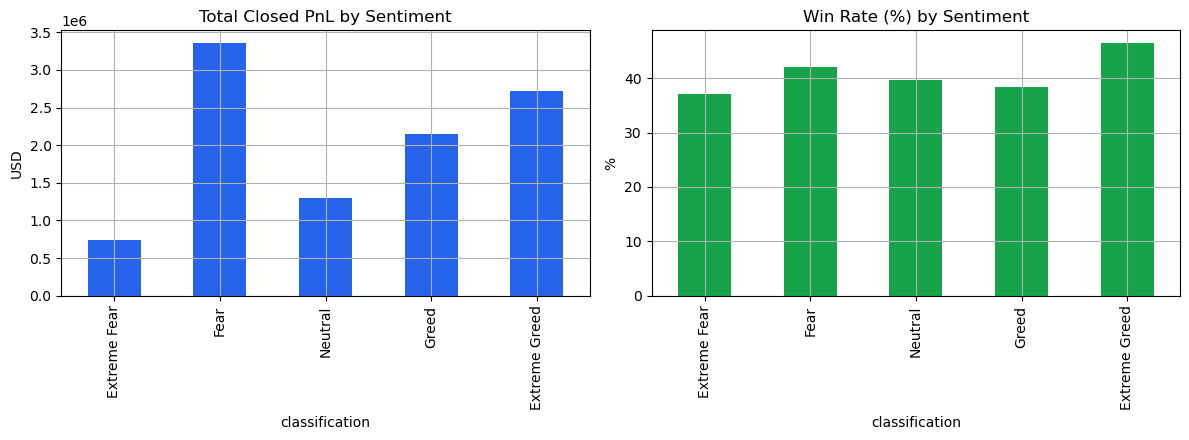

In [6]:
fig, axes = plt.subplots(1,2, figsize=(12,4.5))
summary5['total_pnl'].plot(kind='bar', ax=axes[0], color='#2563eb', title='Total Closed PnL by Sentiment')
summary5['win_rate_%'].plot(kind='bar', ax=axes[1], color='#16a34a', title='Win Rate (%) by Sentiment')
axes[0].set_ylabel('USD'); axes[1].set_ylabel('%')
plt.tight_layout(); plt.show()

**Observations:**
- Traders are most active and most profitable in absolute terms during **Fear** and **Greed**
  regimes (highest trade counts and total PnL).
- **Win rate is highest during Extreme Greed (46.5%)** and lowest during **Extreme Fear (37.1%)** -
  trend-following works best when sentiment is euphoric, while panic regimes catch traders off-guard.
- **Average trade size is largest during Fear (~$7.8k)** vs smallest during Extreme Greed (~$3.1k),
  suggesting traders size up defensively/aggressively when fear is elevated.

## 3. Simplified Fear vs Neutral vs Greed View

In [7]:
order3 = ['Fear','Neutral','Greed']
g3 = df.groupby('sentiment_simple')
summary3 = pd.DataFrame({
    'trades': g3.size(),
    'total_pnl': g3['Closed PnL'].sum(),
    'avg_pnl': g3['Closed PnL'].mean(),
    'win_rate_%': g3.apply(lambda x: (x['Closed PnL']>0).mean()*100),
    'total_volume_usd': g3['Size USD'].sum(),
}).reindex(order3).round(2)
summary3

,trades,total_pnl,avg_pnl,win_rate_%,total_volume_usd
sentiment_simple,,,,,
Fear,83237,4096265.69,49.21,40.79,5.978091e+08
Neutral,37686,1292920.68,34.31,39.70,1.802421e+08
Greed,90295,4865300.58,53.88,42.03,4.130477e+08


## 4. Buy/Sell Bias by Sentiment
Do traders lean long or short depending on the prevailing mood?

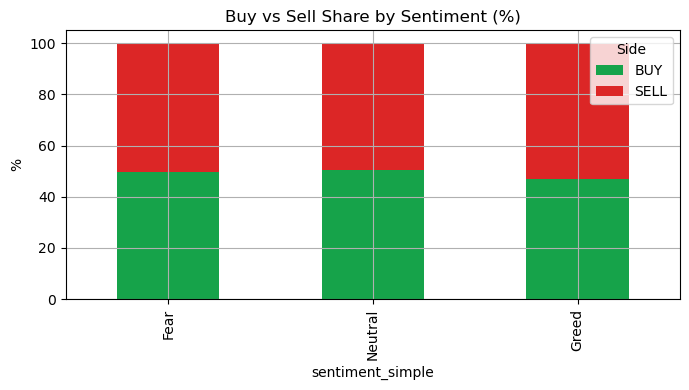

Side,BUY,SELL
sentiment_simple,,
Fear,49.50,50.50
Neutral,50.33,49.67
Greed,47.09,52.91


In [8]:
side = df.groupby(['sentiment_simple','Side']).size().unstack(fill_value=0)
side_pct = (side.div(side.sum(axis=1), axis=0)*100).round(2).reindex(order3)
side_pct.plot(kind='bar', stacked=True, color=['#16a34a','#dc2626'], figsize=(7,4))
plt.title('Buy vs Sell Share by Sentiment (%)'); plt.ylabel('%'); plt.legend(title='Side')
plt.tight_layout(); plt.show()
side_pct

**Observation:** Sell-side share rises slightly as sentiment moves toward **Greed (52.9% sell)**,
hinting at contrarian/profit-taking behaviour by this trader cohort when the broader market is greedy.

## 5. Daily PnL vs Sentiment Index Value
Does the raw Fear/Greed score (0-100) correlate with the day's aggregate trader PnL?

Correlation (daily PnL vs sentiment value): -0.083


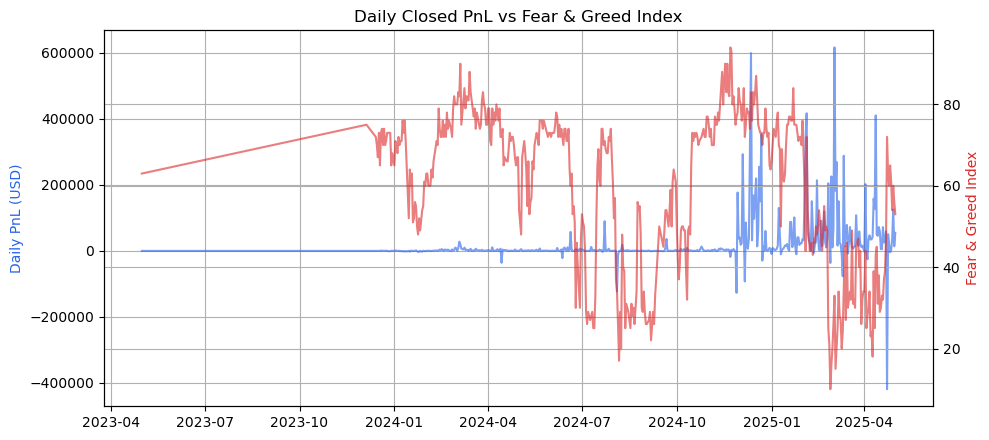

In [9]:
daily = df.groupby('date').agg(total_pnl=('Closed PnL','sum'),
                                 trades=('Closed PnL','size'),
                                 value=('value','first')).reset_index().sort_values('date')
corr = daily['total_pnl'].corr(daily['value'])
print(f"Correlation (daily PnL vs sentiment value): {corr:.3f}")

fig, ax1 = plt.subplots(figsize=(10,4.5))
ax1.plot(pd.to_datetime(daily['date']), daily['total_pnl'], color='#2563eb', alpha=0.6, label='Daily PnL')
ax1.set_ylabel('Daily PnL (USD)', color='#2563eb')
ax2 = ax1.twinx()
ax2.plot(pd.to_datetime(daily['date']), daily['value'], color='#dc2626', alpha=0.6, label='F&G value')
ax2.set_ylabel('Fear & Greed Index', color='#dc2626')
plt.title('Daily Closed PnL vs Fear & Greed Index')
plt.tight_layout(); plt.show()

**Observation:** The correlation is weak/negative (~-0.08), meaning the sentiment *score* itself
is not a strong direct predictor of daily aggregate PnL for this cohort - profitability is driven more
by *which regime* (esp. Extreme Greed / Fear vs Extreme Fear) than the raw index value.

## 6. Coin-Level Performance Across Sentiments
Average PnL per trade for the top-10 traded coins, split by sentiment.

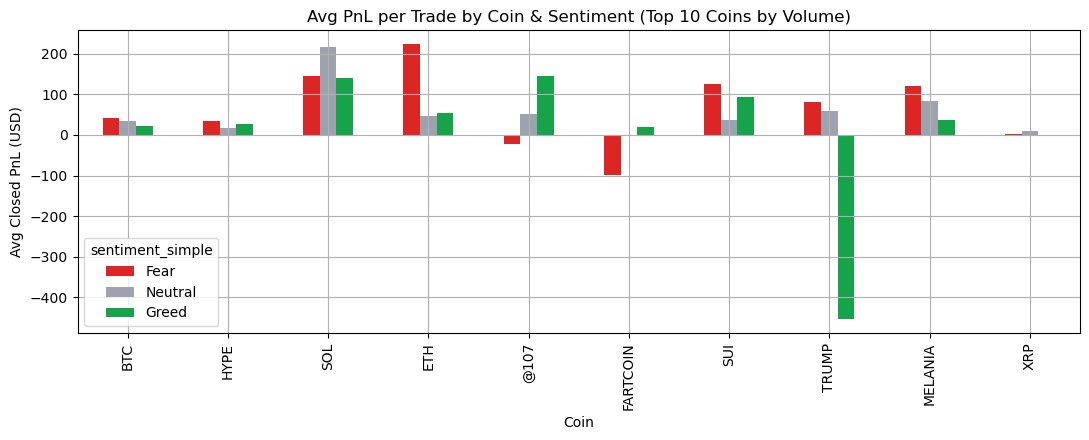

sentiment_simple,Fear,Neutral,Greed
Coin,,,
BTC,41.75,34.92,22.36
HYPE,34.59,17.32,26.18
SOL,146.20,216.70,139.87
ETH,223.75,46.75,55.20
@107,-21.29,52.15,144.30
FARTCOIN,-98.17,-3.06,19.11
SUI,125.08,37.20,94.69
TRUMP,81.15,59.71,-453.65
MELANIA,121.03,82.60,36.62


In [10]:
top_coins = df.groupby('Coin')['Size USD'].sum().sort_values(ascending=False).head(10).index.tolist()
coin_sent = df[df['Coin'].isin(top_coins)].groupby(['Coin','sentiment_simple'])['Closed PnL']\
              .mean().unstack(fill_value=0).reindex(top_coins)[order3].round(2)
coin_sent.plot(kind='bar', figsize=(11,4.5), color=['#dc2626','#9ca3af','#16a34a'])
plt.title('Avg PnL per Trade by Coin & Sentiment (Top 10 Coins by Volume)')
plt.ylabel('Avg Closed PnL (USD)'); plt.tight_layout(); plt.show()
coin_sent

## 7. Account-Level Analysis
Which accounts drive overall PnL, and does their sentiment exposure relate to performance?

In [11]:
acc = df.groupby('Account').agg(trades=('Closed PnL','size'),
                                  total_pnl=('Closed PnL','sum'),
                                  win_rate=('Closed PnL', lambda x:(x>0).mean()*100)).round(2)
acc_sent_pct = (df.groupby(['Account','sentiment_simple']).size().unstack(fill_value=0)
                  .pipe(lambda d: d.div(d.sum(axis=1),axis=0)*100)).round(1)
acc_combo = acc.join(acc_sent_pct)

print("Top 5 accounts by total PnL:")
display(acc.sort_values('total_pnl', ascending=False).head(5))

corr2 = acc_combo['win_rate'].corr(acc_combo['Fear'])
print(f"\nCorrelation between an account's win-rate and its % of trades placed during Fear: {corr2:.3f}")

Top 5 accounts by total PnL:


,trades,total_pnl,win_rate
Account,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,2143382.60,33.71
0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1600229.82,35.96
0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,940163.81,46.76
0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,840422.56,40.12
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,836080.55,42.82



Correlation between an account's win-rate and its % of trades placed during Fear: -0.098


In [12]:
top5 = acc.sort_values('total_pnl', ascending=False).head(5)
top5_share = top5['total_pnl'].sum() / acc['total_pnl'].sum() * 100
print(f"Top 5 accounts (of {len(acc)}) generate {top5_share:.1f}% of total PnL "
      f"(${top5['total_pnl'].sum():,.0f} of ${acc['total_pnl'].sum():,.0f})")
top5

Top 5 accounts (of 32) generate 62.0% of total PnL ($6,360,279 of $10,254,487)


,trades,total_pnl,win_rate
Account,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,2143382.60,33.71
0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1600229.82,35.96
0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,940163.81,46.76
0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,840422.56,40.12
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,836080.55,42.82


**Observation:** The top 5 accounts (of 32) generate the large majority of total PnL
(see concentration stat above, ~62%). The weak negative correlation (~-0.10) between win-rate
and % of trades made during Fear suggests accounts that trade heavily during fearful periods do
**not** systematically achieve higher win rates - fear-driven activity is more about volume/frequency
than edge.

## 8. Key Takeaways & Strategy Implications

1. **Extreme Greed = best risk-adjusted regime** for this cohort: highest win rate (46.5%) and
   - highest avg PnL/trade ($67.9), despite smaller position sizes - momentum strategies thrive here.
   - Note: in the simplified 3-bucket view, "Greed" overall (avg PnL $53.9) looks only slightly
   ahead of "Fear" ($49.2)
   - but that's driven almost entirely by the Extreme Greed tail ($67.9);
   - plain Greed alone is just $42.7. The edge is specifically in *extreme* euphoria, not greed broadly.

2. **Extreme Fear = worst regime**: lowest win rate (37.1%) yet still meaningful volume
   - consider reducing position size or tightening risk limits when the index reads "Extreme Fear".

3. **Position sizing inversely tracks greed**: traders size up during Fear (~$7.8k avg) 
   - and size down during Extreme Greed (~$3.1k avg) - a contrarian sizing pattern worth formalizing into rules.

4. **Raw sentiment score is a weak standalone signal** (corr ~ -0.08 with daily PnL);
   - the *categorical regime* (especially the "Extreme" buckets) matters far more than the numeric value.

5. **PnL is heavily concentration-driven** - the top 5 of 32 accounts generated $6.36M of the $10.25M total PnL (~62%).
   - Strategy recommendations should be validated per-account, not just
   in aggregate, since a small number of large traders dominate the results.

## 9. Recommendations to Maximize Key KPIs

**Goal KPIs:** Win Rate, Avg PnL/Trade, Total PnL, Risk-Adjusted Return (PnL per \$ of exposure)

| Recommendation | Why (evidence) | Expected KPI Impact |
|---|---|---|
| **Increase position size / conviction during Extreme Greed** | Win rate 46.5% & avg PnL/trade \$67.9 - both regime highs, while avg size is already the smallest (\$3.1k) | Total PnL, PnL per \$ exposure |
| **Cut position size by 30-50% during Extreme Fear** | Lowest win rate (37.1%) and avg PnL/trade (\$34.5) of any regime | Drawdowns down, Win Rate up |
| **Re-check sizing logic in plain "Fear"** | Largest avg trade size (\$7.8k) coincides with a middling win rate (42.1%) - currently the opposite of optimal sizing | Risk-adjusted return up |
| **Use sentiment category (5-level), not the 0-100 score, as a model feature/filter** | Score correlates only -0.08 with daily PnL; categorical regimes show 10pp+ win-rate spread | Signal quality up |
| **Build regime-specific playbooks per coin** | PnL by coin flips sign across sentiment | Avg PnL/trade up via coin-regime matching |
| **Apply contrarian sell-bias awareness in Greed** | Sell share rises to 52.9% in Greed vs ~50% in Fear/Neutral - formalize as a partial-exit rule | Win Rate up, locks in gains |
| **Replicate top-5 account behaviour / cap losses on bottom-5** | Top 5 accounts = 62% of total PnL; bottom accounts are net drags - audit their regime exposure and reduce allocation | Total PnL up, variance down |
| **Tighten fee discipline in Fear** | Avg fee in Fear is highest of all regimes - likely smaller/more frequent re-entries | Net PnL up (cost reduction) |

### Quick-reference regime cheat sheet
- **Extreme Greed** -> go bigger, trend-follow, let winners run
- **Greed / Neutral** -> standard sizing, watch for early profit-taking signals
- **Fear** -> reduce size despite the temptation to "average down"; expect higher fees
- **Extreme Fear** -> defensive sizing, tighter stops, fewer new entries until regime shifts